In [2]:
# FRAUD INTELLIGENCE PROJECT — EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import networkx as nx

from IPython.display import display

# LOAD FINAL DASHBOARD DATASETS

accounts = pd.read_csv("accounts_cleaned.csv")
transactions = pd.read_csv("transactions_dashboard_ready.csv")
alerts = pd.read_csv("alerts_cleaned.csv")

datasets = {
    "Accounts": accounts,
    "Transactions": transactions,
    "Alerts": alerts
}

print(
    f"accounts: {len(accounts)}, "
    f"transactions: {len(transactions)}, "
    f"alerts: {len(alerts)}"
)

# Integrity check
account_ids = set(accounts["account_id"])

orphan_senders = (
    ~transactions["sender_account_id"].isin(account_ids)
).sum()

orphan_receivers = (
    ~transactions["receiver_account_id"].isin(account_ids)
).sum()

print(
    f"Orphan senders: {orphan_senders}, "
    f"Orphan receivers: {orphan_receivers}"
)

accounts: 1000, transactions: 1000, alerts: 1000
Orphan senders: 949, Orphan receivers: 969


In [3]:
# 3. DATA-TYPE ANALYSIS

print("\n" + "=" * 70)
print("3. DATA-TYPE ANALYSIS")
print("=" * 70)

for name, data in datasets.items():

    print(f"\n{name}")
    print("-" * 40)

    dtype_table = pd.DataFrame({
        "Column": data.columns,
        "Data_Type": data.dtypes.astype(str).values,
        "Unique_Values": [
            data[col].nunique(dropna=True)
            for col in data.columns
        ],
        "Missing_Values": [
            data[col].isnull().sum()
            for col in data.columns
        ]
    })

    display(dtype_table)


3. DATA-TYPE ANALYSIS

Accounts
----------------------------------------


,Column,Data_Type,Unique_Values,Missing_Values
0,account_id,int64,1000,0
1,customer_id,str,1000,0
2,init_balance,float64,987,0
3,country,str,1,0
4,account_type,str,1,0
5,is_fraud,int64,2,0
6,tx_behavior_segment,int64,5,0



Transactions
----------------------------------------


,Column,Data_Type,Unique_Values,Missing_Values
0,tx_id,int64,1000,0
1,sender_account_id,int64,915,0
2,receiver_account_id,int64,884,0
3,tx_type,str,1,0
4,tx_amount,float64,883,0
5,tx_time_step,int64,200,0
6,is_fraud,bool,2,0
7,alert_id,int64,3,0
8,amount_anomaly_flag,str,2,0



Alerts
----------------------------------------


,Column,Data_Type,Unique_Values,Missing_Values
0,tx_id,int64,1000,0
1,alert_id,int64,228,0
2,alert_type,str,2,0
3,is_fraud,int64,1,0
4,sender_account_id,int64,916,0
5,receiver_account_id,int64,635,0
6,tx_type,str,1,0
7,tx_amount,float64,288,0
8,tx_time_step,int64,119,0


In [4]:
# ============================================================
# 4. CATEGORICAL CONSISTENCY ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("4. CATEGORICAL CONSISTENCY ANALYSIS")
print("=" * 70)

for name, data in datasets.items():

    print(f"\n{name}")
    print("-" * 40)

    categorical_columns = data.select_dtypes(
        include=["object", "category", "bool"]
    ).columns

    if len(categorical_columns) == 0:
        print("No categorical columns found.")
        continue

    for col in categorical_columns:

        print(f"\nColumn: {col}")

        print(
            f"Unique values: "
            f"{data[col].nunique(dropna=True)}"
        )

        values = data[col].dropna().astype(str)

        # Leading/trailing spaces
        whitespace_values = values[
            values.str.strip() != values
        ]

        # Case/format duplicates
        normalized = (
            values
            .str.strip()
            .str.lower()
        )

        inconsistent_case = (
            normalized.value_counts()
            .loc[lambda x: x > 1]
        )

        print(
            f"Values with leading/trailing spaces: "
            f"{len(whitespace_values)}"
        )

        print(
            f"Potential case/format duplicates: "
            f"{len(inconsistent_case)}"
        )

        print("Top categories:")

        print(
            data[col]
            .value_counts(dropna=False)
            .head(15)
        )


4. CATEGORICAL CONSISTENCY ANALYSIS

Accounts
----------------------------------------

Column: customer_id
Unique values: 1000
Values with leading/trailing spaces: 0
Potential case/format duplicates: 0
Top categories:
customer_id
C_0     1
C_1     1
C_2     1
C_3     1
C_4     1
C_5     1
C_6     1
C_7     1
C_8     1
C_9     1
C_10    1
C_11    1
C_12    1
C_13    1
C_14    1
Name: count, dtype: int64

Column: country
Unique values: 1
Values with leading/trailing spaces: 0
Potential case/format duplicates: 1
Top categories:
country
US    1000
Name: count, dtype: int64

Column: account_type
Unique values: 1
Values with leading/trailing spaces: 0
Potential case/format duplicates: 1
Top categories:
account_type
I    1000
Name: count, dtype: int64

Transactions
----------------------------------------

Column: tx_type
Unique values: 1
Values with leading/trailing spaces: 0
Potential case/format duplicates: 1
Top categories:
tx_type
TRANSFER    1000
Name: count, dtype: int64

Column: is_

/var/folders/07/c63bxvps49vdr28x9jk6wfch0000gn/T/ipykernel_78410/70446447.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = data.select_dtypes(
/var/folders/07/c63bxvps49vdr28x9jk6wfch0000gn/T/ipykernel_78410/70446447.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/d

In [5]:
# 5. OUTLIER ANALYSIS USING IQR

print("\n" + "=" * 70)
print("5. OUTLIER ANALYSIS — IQR METHOD")
print("=" * 70)


def iqr_outlier_analysis(data, dataset_name):

    numeric_columns = data.select_dtypes(
        include=np.number
    ).columns

    results = []

    for col in numeric_columns:

        series = data[col].dropna()

        if len(series) < 4:
            continue

        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = series[
            (series < lower_bound) |
            (series > upper_bound)
        ]

        results.append({
            "Dataset": dataset_name,
            "Column": col,
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower_Bound": lower_bound,
            "Upper_Bound": upper_bound,
            "Outlier_Count": len(outliers),
            "Outlier_Percentage": (
                len(outliers) / len(series)
            ) * 100
        })

    return pd.DataFrame(results)


outlier_results = pd.concat(
    [
        iqr_outlier_analysis(data, name)
        for name, data in datasets.items()
    ],
    ignore_index=True
)

display(
    outlier_results.sort_values(
        "Outlier_Count",
        ascending=False
    )
)


5. OUTLIER ANALYSIS — IQR METHOD


,Dataset,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
2,Accounts,is_fraud,0.0000,0.0000,0.000,0.0000,0.000000e+00,78,7.8
7,Transactions,tx_amount,23.3475,440.7425,417.395,-602.7450,1.066835e+03,33,3.3
9,Transactions,alert_id,-1.0000,-1.0000,0.000,-1.0000,-1.000000e+00,2,0.2
0,Accounts,account_id,249.7500,749.2500,499.500,-499.5000,1.498500e+03,0,0.0
10,Alerts,tx_id,208788.5000,559925.2500,351136.750,-317916.6250,1.086630e+06,0,0.0
15,Alerts,tx_amount,3.8700,15.4200,11.550,-13.4550,3.274500e+01,0,0.0
14,Alerts,receiver_account_id,4175.7500,9373.2500,5197.500,-3620.5000,1.716950e+04,0,0.0
13,Alerts,sender_account_id,4160.2500,9222.5000,5062.250,-3433.1250,1.681588e+04,0,0.0
12,Alerts,is_fraud,1.0000,1.0000,0.000,1.0000,1.000000e+00,0,0.0
11,Alerts,alert_id,102.0000,315.0000,213.000,-217.5000,6.345000e+02,0,0.0



6. DISTRIBUTION ANALYSIS


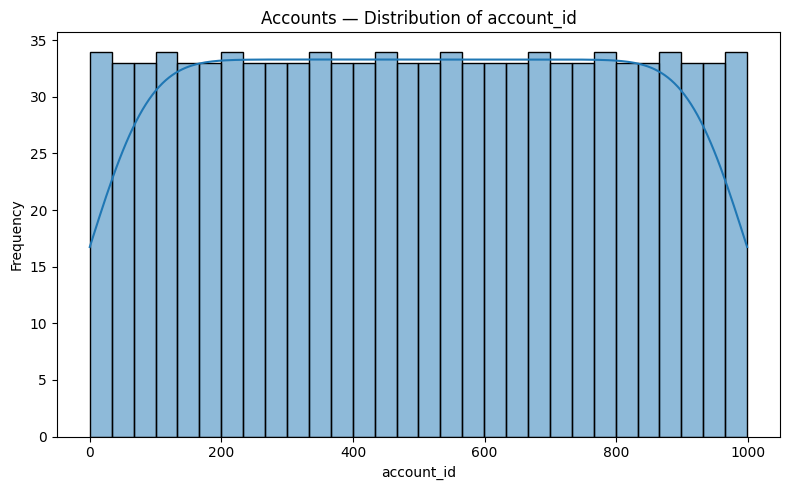

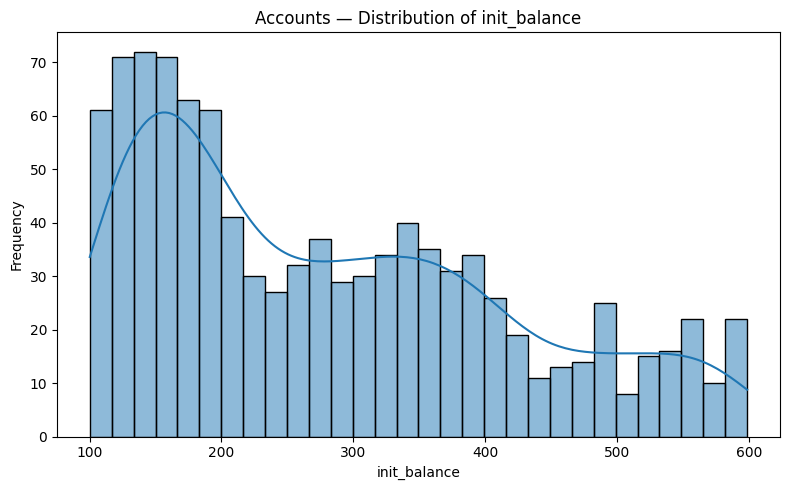

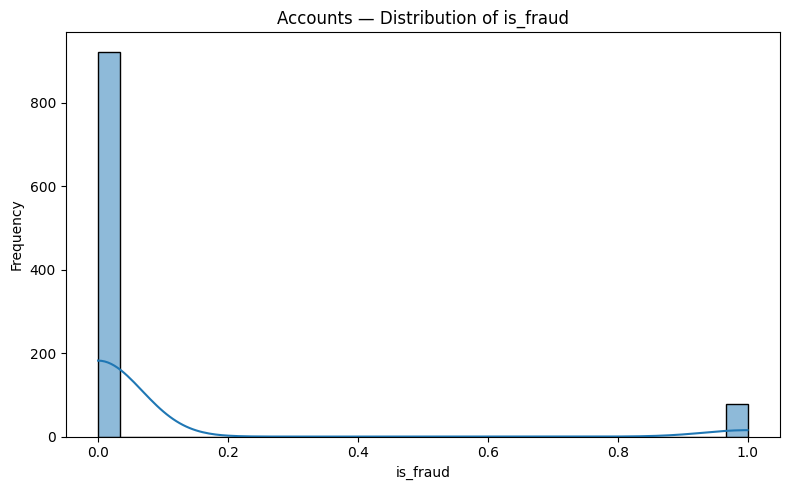

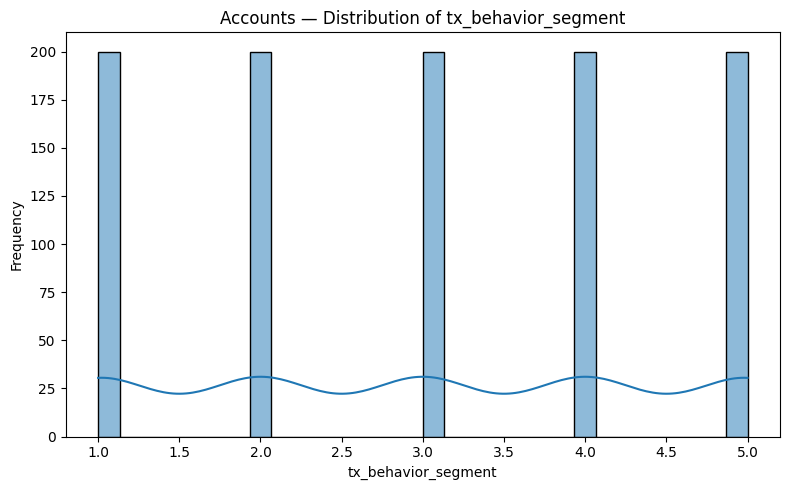

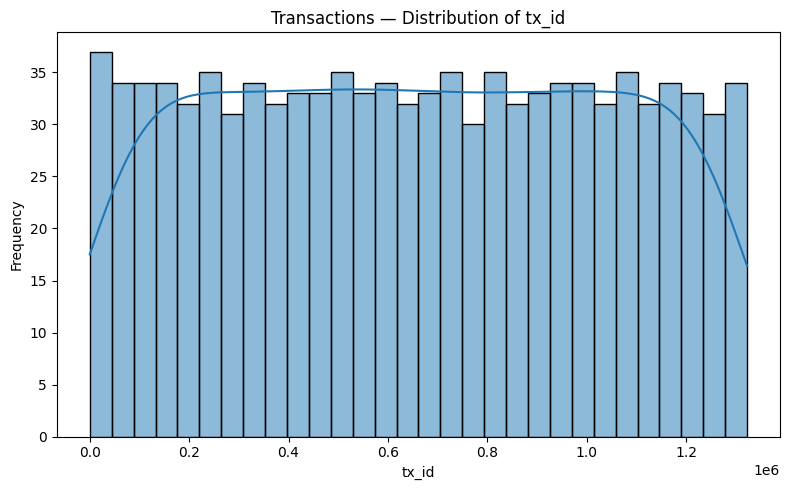

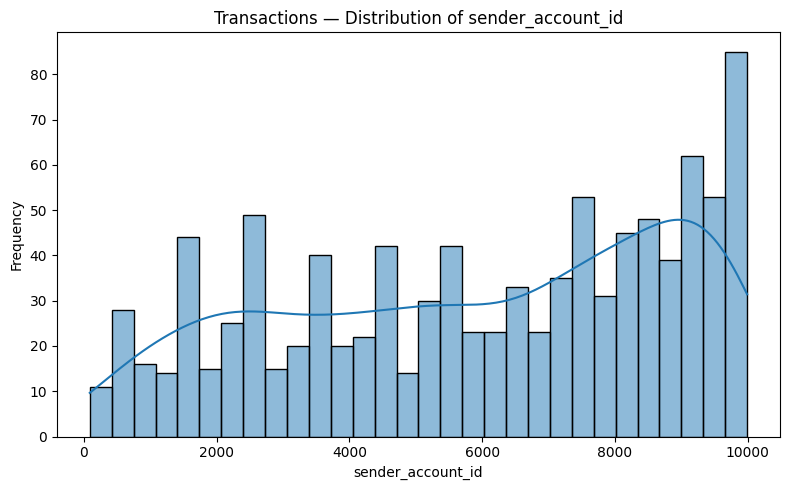

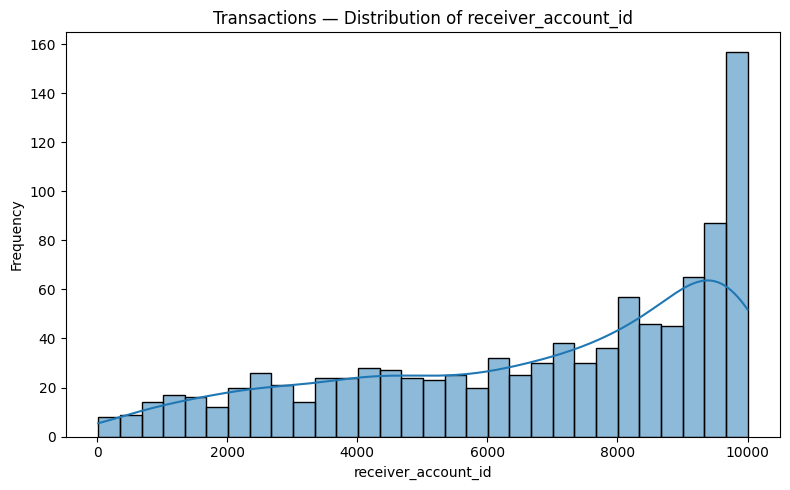

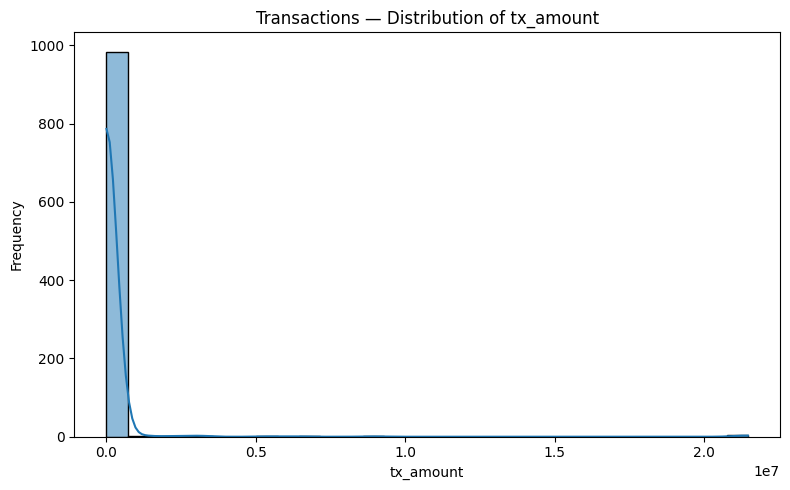

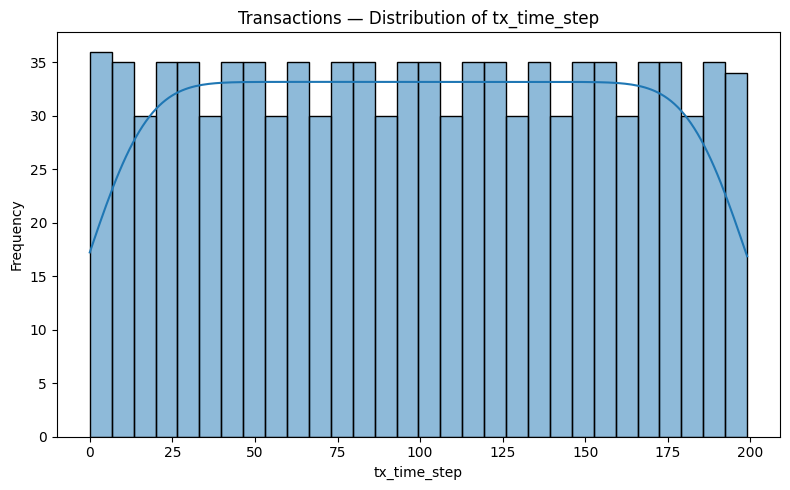

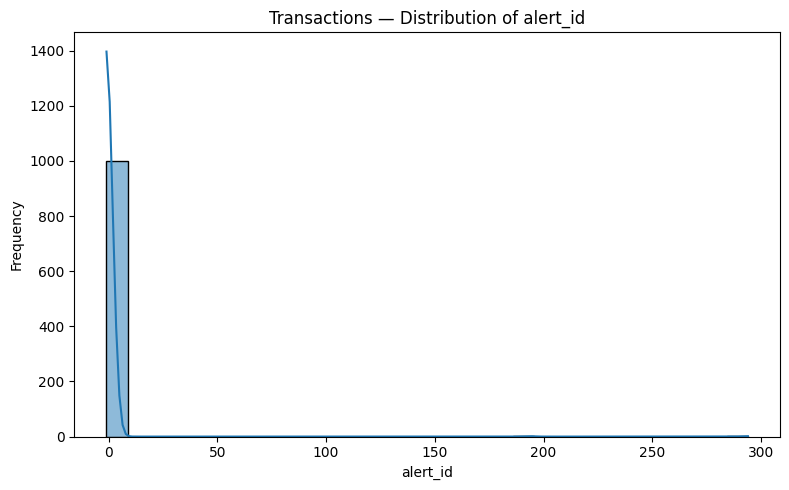

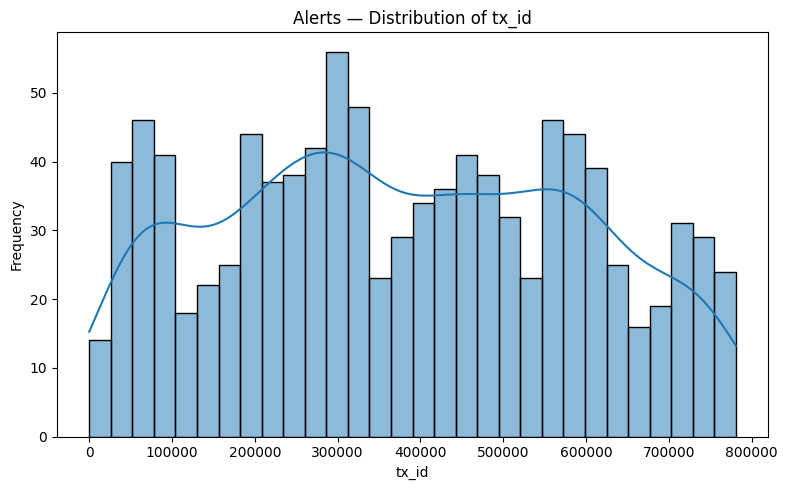

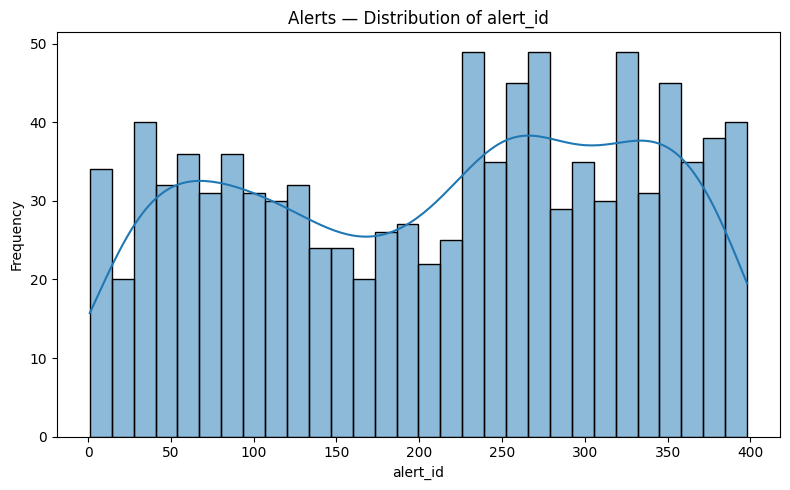

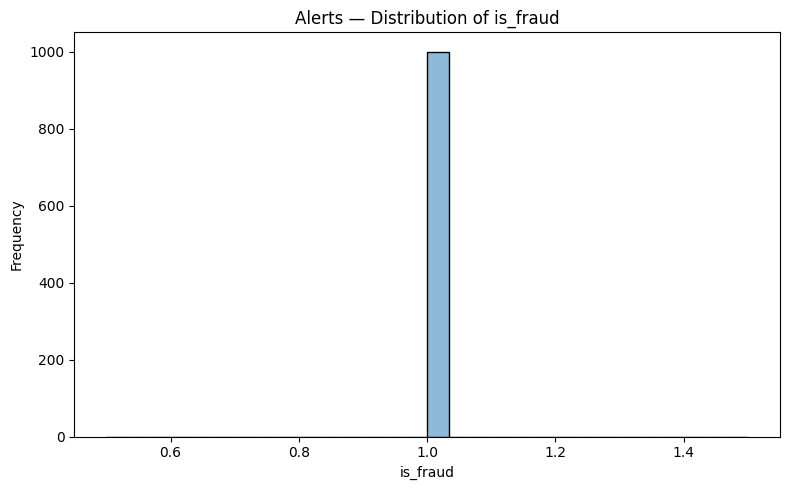

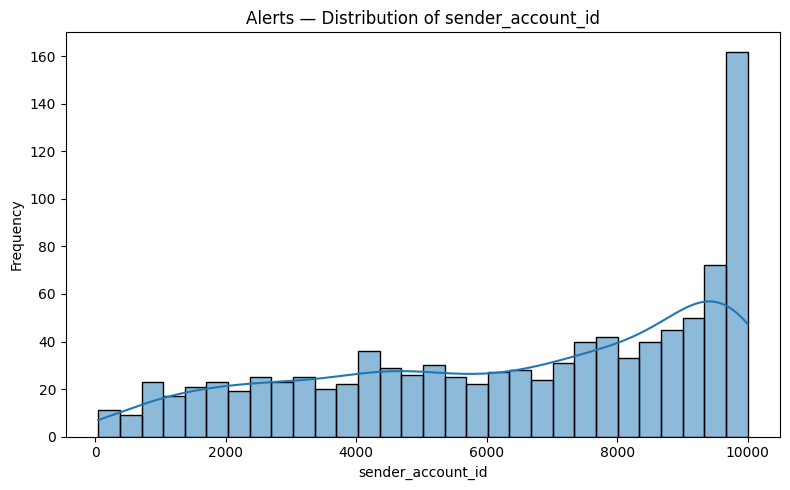

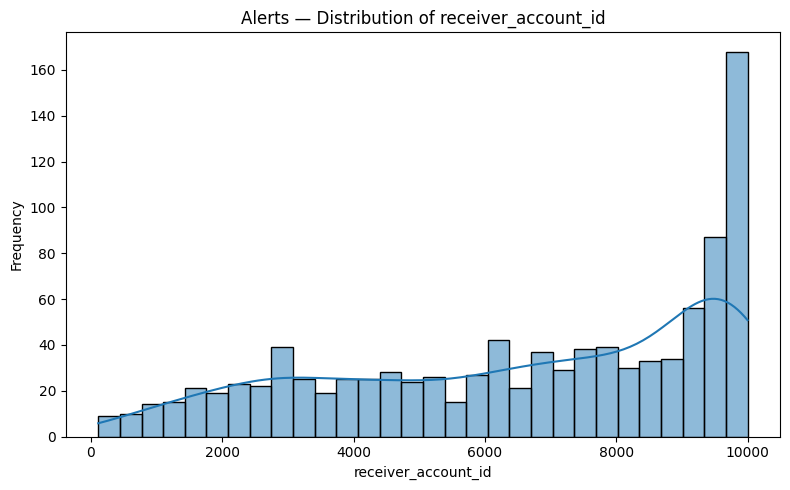

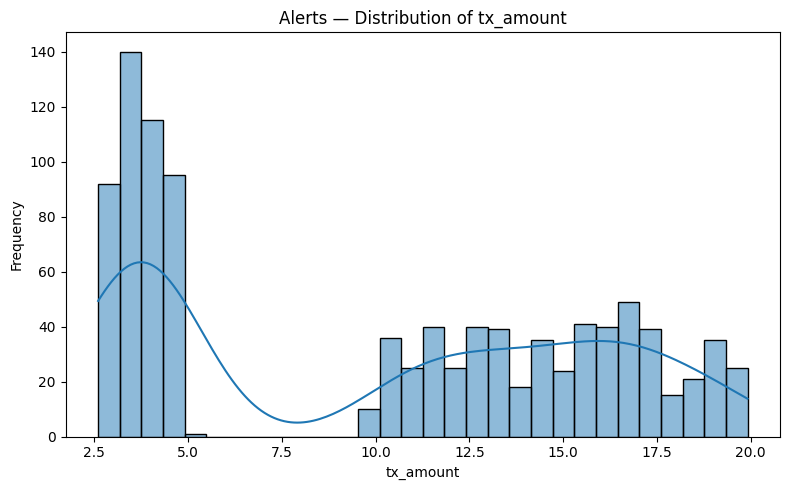

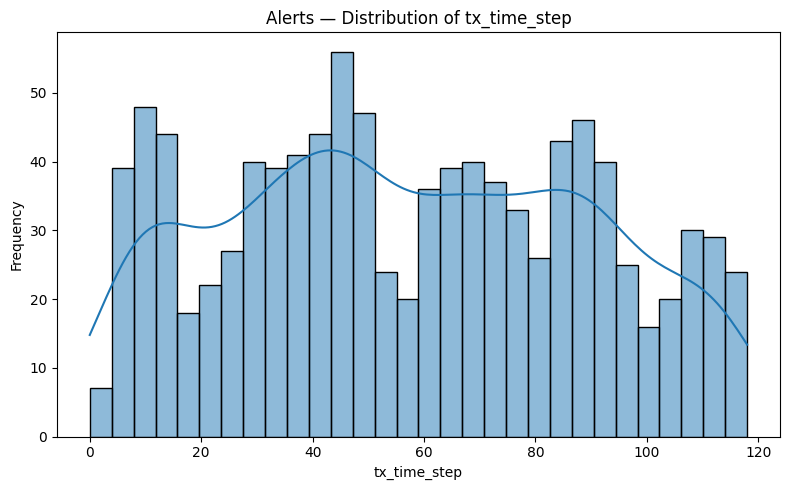

In [6]:
# ============================================================
# 6. DISTRIBUTION ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("6. DISTRIBUTION ANALYSIS")
print("=" * 70)

for name, data in datasets.items():

    numeric_columns = data.select_dtypes(
        include=np.number
    ).columns

    for col in numeric_columns:

        plt.figure(figsize=(8, 5))

        sns.histplot(
            data[col].dropna(),
            kde=True,
            bins=30
        )

        plt.title(
            f"{name} — Distribution of {col}"
        )

        plt.xlabel(col)
        plt.ylabel("Frequency")

        plt.tight_layout()
        plt.show()

Generating boxplots for numerical variables...


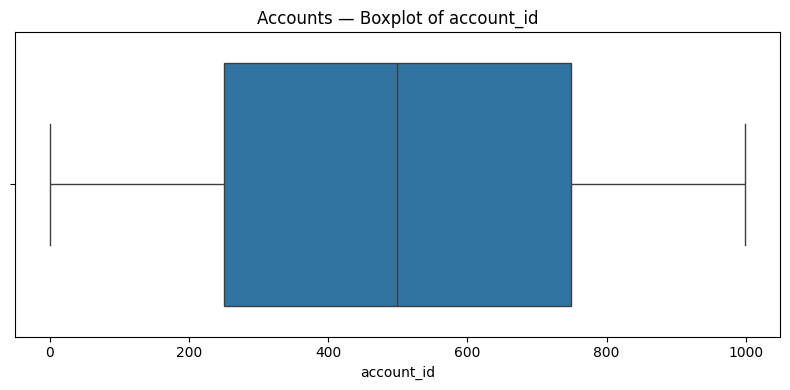

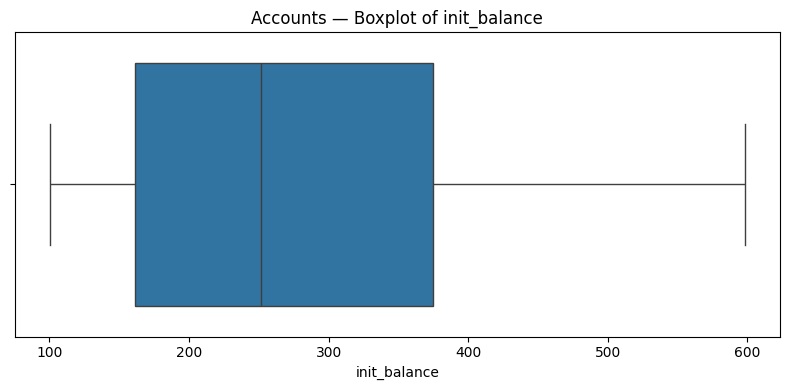

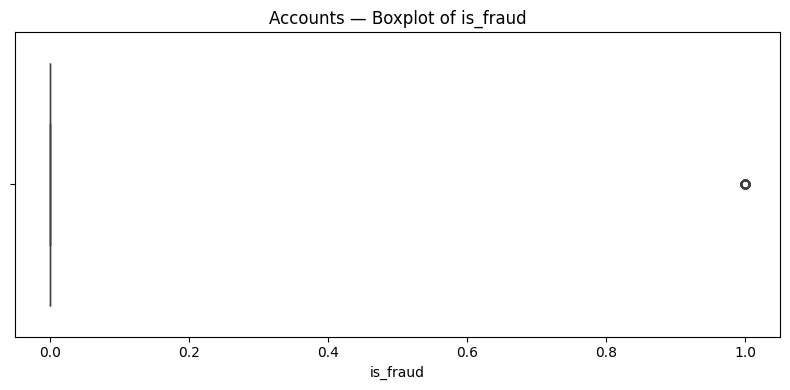

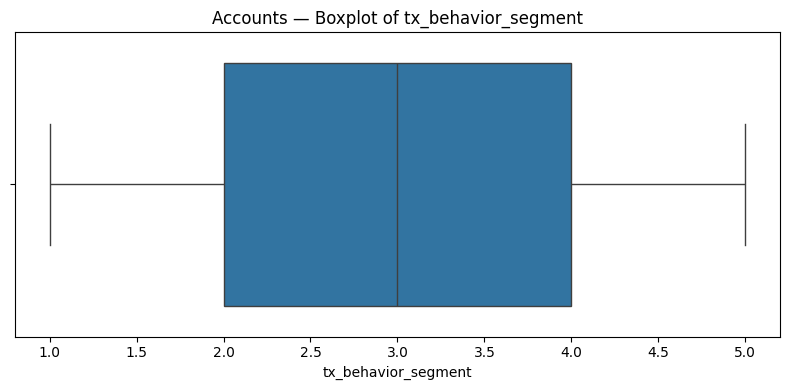

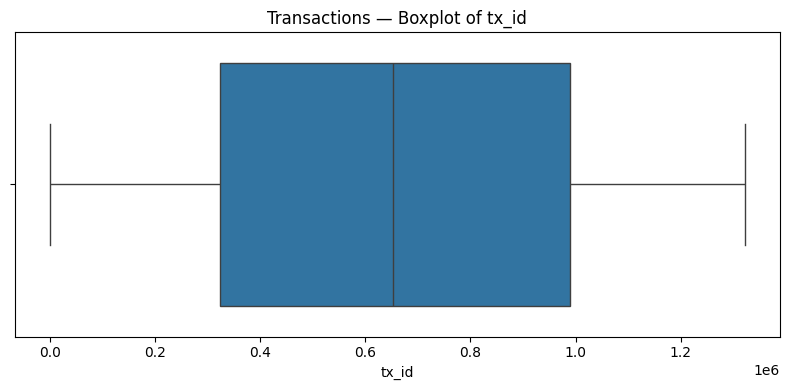

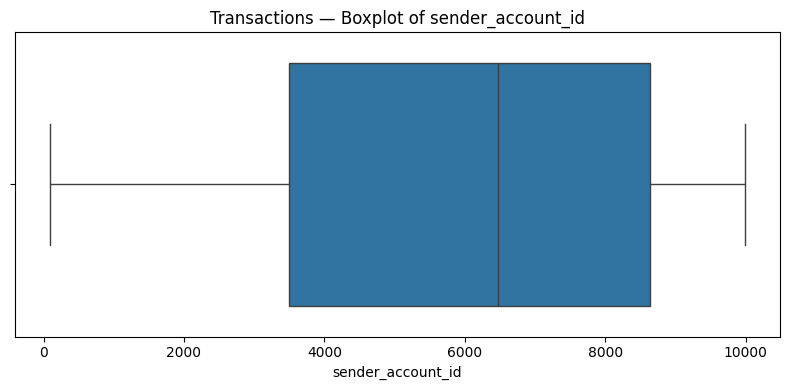

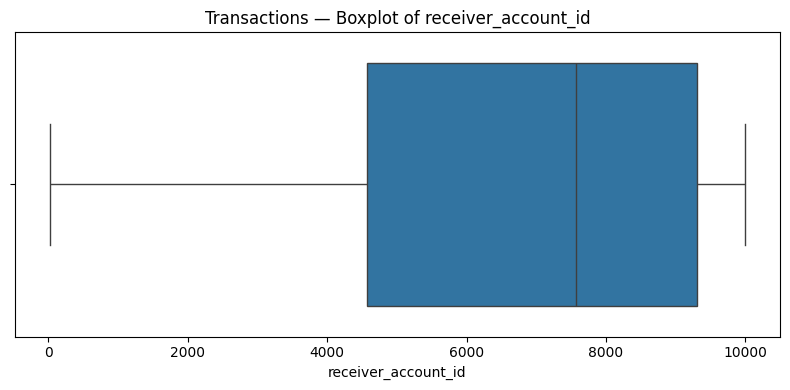

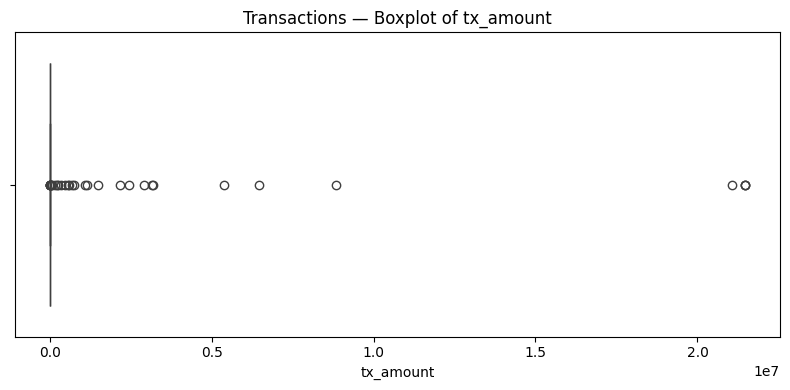

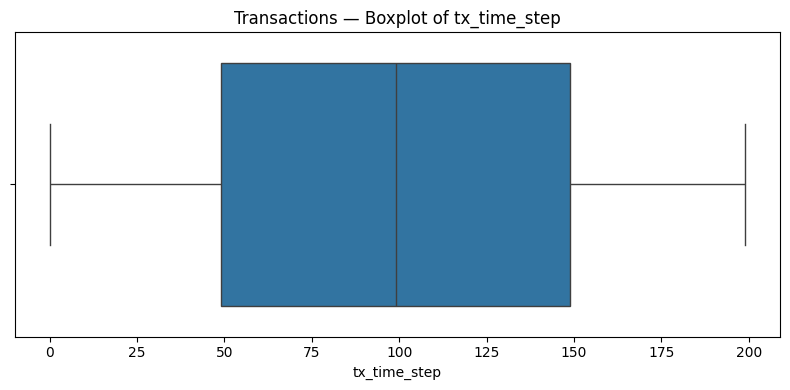

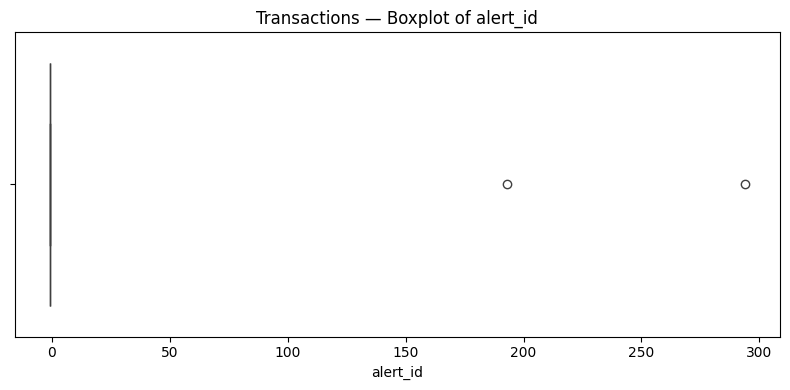

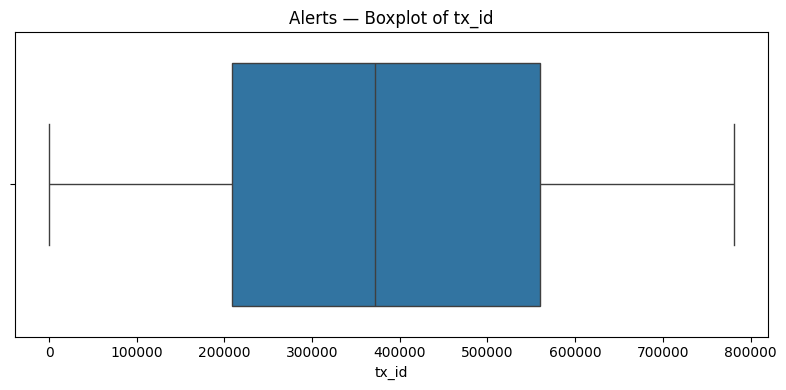

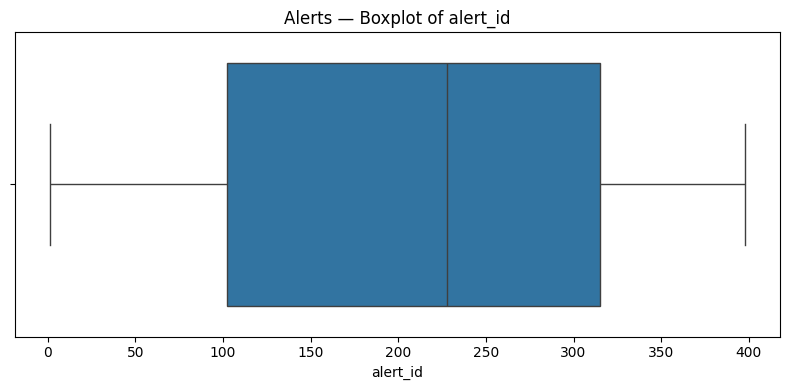

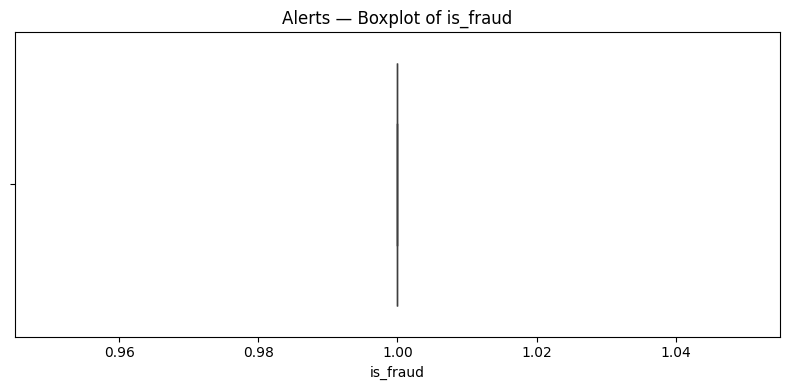

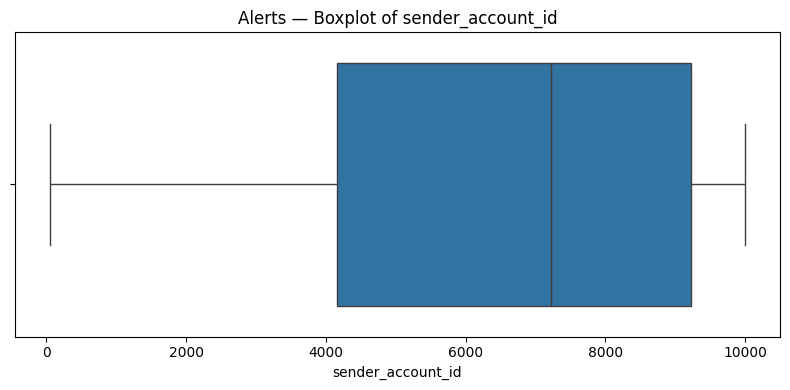

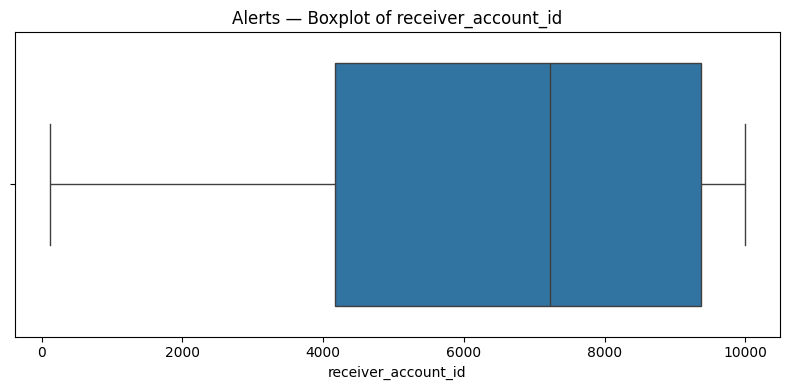

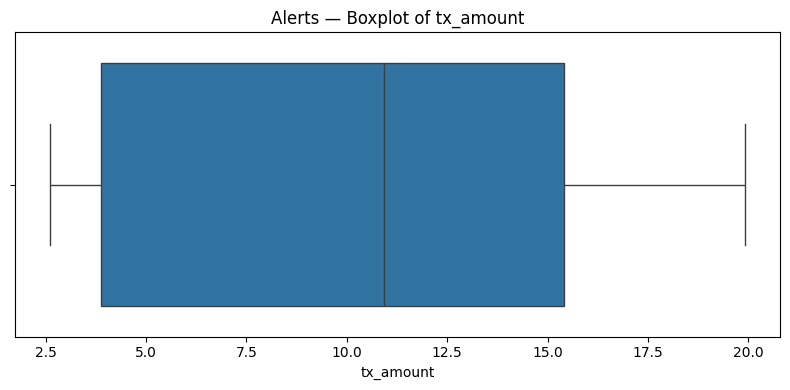

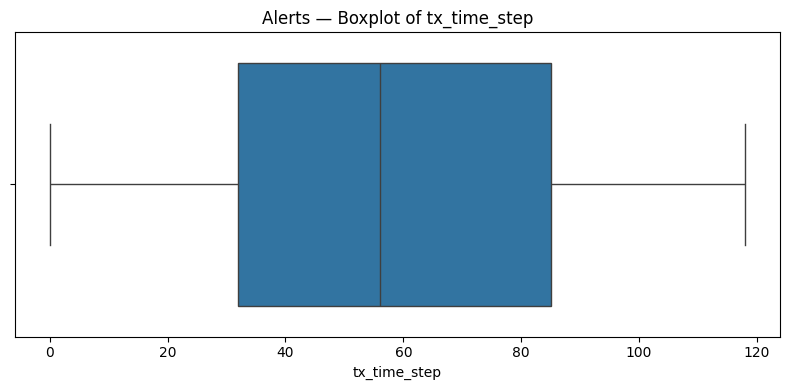

In [7]:
print("Generating boxplots for numerical variables...")

for name, data in datasets.items():

    numeric_columns = data.select_dtypes(
        include=np.number
    ).columns

    for col in numeric_columns:

        plt.figure(figsize=(8, 4))

        sns.boxplot(
            x=data[col].dropna()
        )

        plt.title(
            f"{name} — Boxplot of {col}"
        )

        plt.xlabel(col)

        plt.tight_layout()
        plt.show()


7. BIVARIATE ANALYSIS


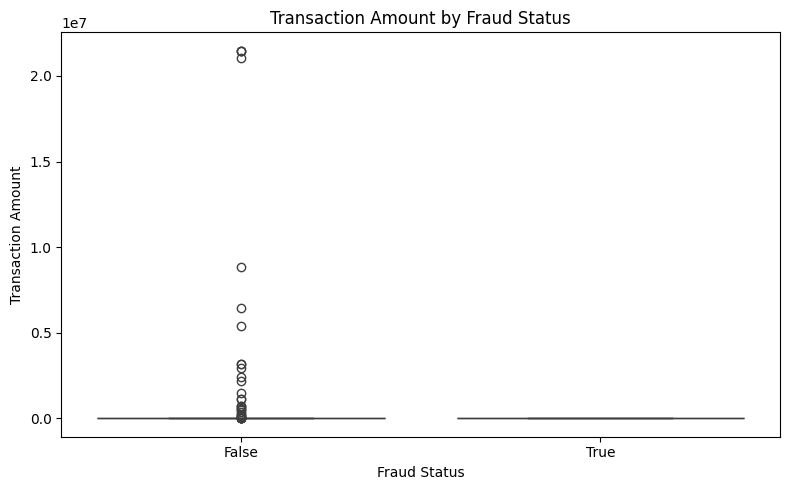

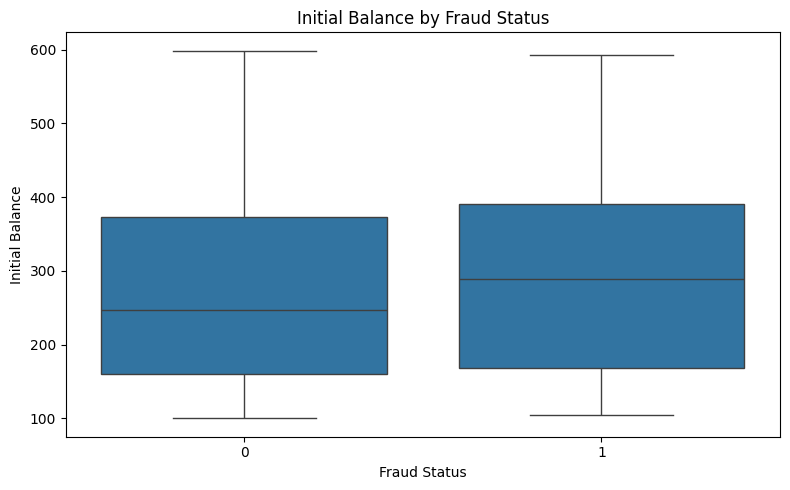


Fraud rate by transaction behavior segment:


,tx_behavior_segment,Account_Count,Fraud_Count,Fraud_Rate
4,5,200,22,11.0
3,4,200,19,9.5
2,3,200,18,9.0
0,1,200,10,5.0
1,2,200,9,4.5


In [9]:
# ============================================================
# 7. BIVARIATE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("7. BIVARIATE ANALYSIS")
print("=" * 70)
if {
    "is_fraud",
    "tx_amount"
}.issubset(transactions.columns):

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=transactions,
        x="is_fraud",
        y="tx_amount"
    )

    plt.title(
        "Transaction Amount by Fraud Status"
    )

    plt.xlabel("Fraud Status")
    plt.ylabel("Transaction Amount")

    plt.tight_layout()
    plt.show()

if {
    "is_fraud",
    "init_balance"
}.issubset(accounts.columns):

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=accounts,
        x="is_fraud",
        y="init_balance"
    )

    plt.title(
        "Initial Balance by Fraud Status"
    )

    plt.xlabel("Fraud Status")
    plt.ylabel("Initial Balance")

    plt.tight_layout()
    plt.show()

if {
    "is_fraud",
    "tx_behavior_segment"
}.issubset(accounts.columns):

    behavior_summary = (
        accounts
        .groupby("tx_behavior_segment")["is_fraud"]
        .agg(
            Account_Count="count",
            Fraud_Count="sum",
            Fraud_Rate="mean"
        )
        .reset_index()
    )

    behavior_summary["Fraud_Rate"] *= 100

    print("\nFraud rate by transaction behavior segment:")

    display(
        behavior_summary.sort_values(
            "Fraud_Rate",
            ascending=False
        )
    )


8. MULTIVARIATE ANALYSIS


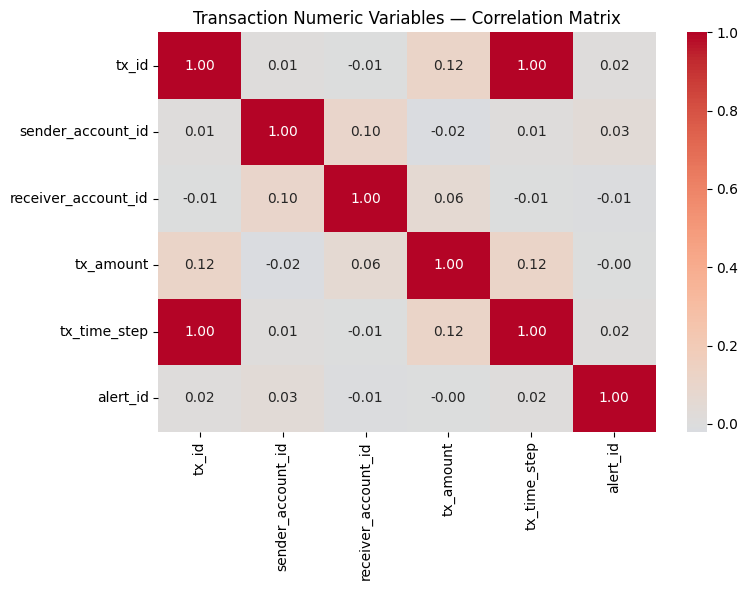

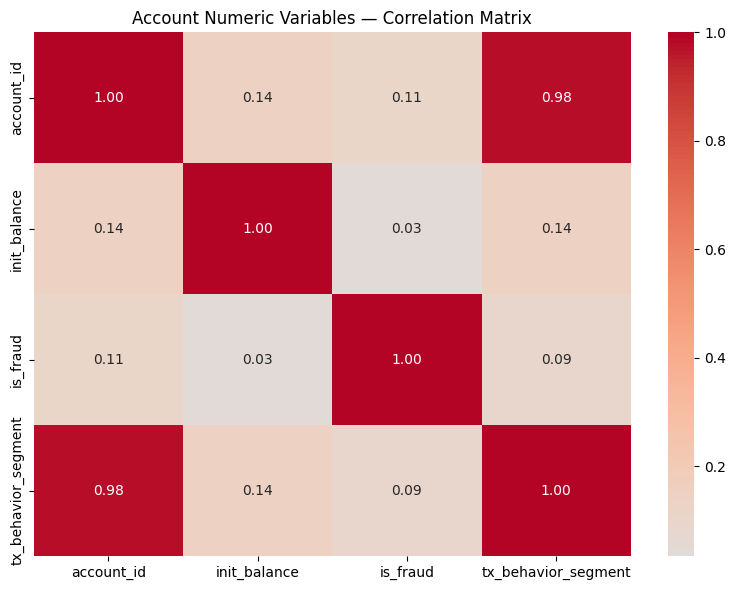


Fraud rate across behavior segment + balance band:


,tx_behavior_segment,balance_band,Account_Count,Fraud_Count,Fraud_Rate
8,5,"(302.37, 399.914]",102,16,15.686275
5,4,"(100.109, 148.452]",109,11,10.091743
4,3,"(399.914, 598.59]",200,18,9.000000
6,4,"(148.452, 200.108]",91,8,8.791209
7,5,"(200.108, 302.37]",98,6,6.122449
1,1,"(148.452, 200.108]",109,6,5.504587
2,2,"(200.108, 302.37]",102,5,4.901961
0,1,"(100.109, 148.452]",91,4,4.395604
3,2,"(302.37, 399.914]",98,4,4.081633


In [10]:
# ============================================================
# 8. MULTIVARIATE ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("8. MULTIVARIATE ANALYSIS")
print("=" * 70)

transaction_numeric = transactions.select_dtypes(
    include=np.number
)

if transaction_numeric.shape[1] >= 2:

    plt.figure(
        figsize=(
            max(8, transaction_numeric.shape[1] * 0.8),
            max(6, transaction_numeric.shape[1] * 0.7)
        )
    )

    correlation_matrix = transaction_numeric.corr()

    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )

    plt.title(
        "Transaction Numeric Variables — Correlation Matrix"
    )

    plt.tight_layout()
    plt.show()

account_numeric = accounts.select_dtypes(
    include=np.number
)

if account_numeric.shape[1] >= 2:

    plt.figure(
        figsize=(
            max(8, account_numeric.shape[1] * 0.8),
            max(6, account_numeric.shape[1] * 0.7)
        )
    )

    account_corr = account_numeric.corr()

    sns.heatmap(
        account_corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )

    plt.title(
        "Account Numeric Variables — Correlation Matrix"
    )

    plt.tight_layout()
    plt.show()

if {
    "is_fraud",
    "tx_behavior_segment",
    "init_balance"
}.issubset(accounts.columns):

    accounts_temp = accounts.copy()

    accounts_temp["balance_band"] = pd.qcut(
        accounts_temp["init_balance"],
        q=5,
        duplicates="drop"
    )

    multi_summary = (
        accounts_temp
        .groupby(
            [
                "tx_behavior_segment",
                "balance_band"
            ],
            observed=True
        )["is_fraud"]
        .agg(
            Account_Count="count",
            Fraud_Count="sum",
            Fraud_Rate="mean"
        )
        .reset_index()
    )

    multi_summary["Fraud_Rate"] *= 100

    print(
        "\nFraud rate across behavior segment + balance band:"
    )

    display(
        multi_summary.sort_values(
            "Fraud_Rate",
            ascending=False
        )
    )

In [11]:
# ============================================================
# 9. STATISTICAL HYPOTHESIS TESTING
# ============================================================

print("\n" + "=" * 70)
print("9. STATISTICAL HYPOTHESIS TESTING")
print("=" * 70)


if {
    "is_fraud",
    "tx_amount"
}.issubset(transactions.columns):

    fraud_amounts = transactions.loc[
        transactions["is_fraud"] == 1,
        "tx_amount"
    ].dropna()

    nonfraud_amounts = transactions.loc[
        transactions["is_fraud"] == 0,
        "tx_amount"
    ].dropna()

    print("\nMann-Whitney U Test")

    print(
        "H0: Fraud and non-fraud transactions have the "
        "same transaction amount distribution."
    )

    print(
        "H1: Their transaction amount distributions differ."
    )

    if (
        len(fraud_amounts) > 0
        and len(nonfraud_amounts) > 0
    ):

        statistic, p_value = stats.mannwhitneyu(
            fraud_amounts,
            nonfraud_amounts,
            alternative="two-sided"
        )

        print(
            f"\nU statistic: {statistic:,.2f}"
        )

        print(
            f"p-value    : {p_value:.6f}"
        )

        if p_value < 0.05:

            print(
                "Conclusion: Reject H0 — there is a "
                "statistically significant difference "
                "in transaction amounts."
            )

        else:

            print(
                "Conclusion: Fail to reject H0 — no "
                "statistically significant difference detected."
            )


9. STATISTICAL HYPOTHESIS TESTING

Mann-Whitney U Test
H0: Fraud and non-fraud transactions have the same transaction amount distribution.
H1: Their transaction amount distributions differ.

U statistic: 99.00
p-value    : 0.027667
Conclusion: Reject H0 — there is a statistically significant difference in transaction amounts.


In [12]:
if {
    "is_fraud",
    "tx_behavior_segment"
}.issubset(accounts.columns):

    contingency_table = pd.crosstab(
        accounts["tx_behavior_segment"],
        accounts["is_fraud"]
    )

    print("\nChi-Square Test")

    print(
        "Testing whether transaction behavior segment "
        "and fraud status are associated."
    )

    display(contingency_table)

    chi2, p_value, dof, expected = stats.chi2_contingency(
        contingency_table
    )

    print(
        f"\nChi-square statistic: {chi2:.4f}"
    )

    print(
        f"Degrees of freedom : {dof}"
    )

    print(
        f"p-value            : {p_value:.6f}"
    )

    if p_value < 0.05:

        print(
            "Conclusion: Reject H0 — behavior segment "
            "and fraud status are statistically associated."
        )

    else:

        print(
            "Conclusion: Fail to reject H0 — insufficient "
            "evidence of an association."
        )


Chi-Square Test
Testing whether transaction behavior segment and fraud status are associated.


is_fraud,0,1
tx_behavior_segment,,
1,190,10
2,191,9
3,182,18
4,181,19
5,178,22



Chi-square statistic: 9.2608
Degrees of freedom : 4
p-value            : 0.054901
Conclusion: Fail to reject H0 — insufficient evidence of an association.


# Key EDA Findings

The exploratory analysis identified several patterns in the banking transaction data:

1. Transaction-level fraud shows a highly imbalanced distribution between fraudulent and non-fraudulent transactions.

2. Transaction amount distributions were examined across fraud status using bivariate analysis.

3. IQR analysis was used to identify potential numerical outliers.

4. Distribution analysis highlighted the spread and skewness of key numerical variables.

5. Multivariate analysis was performed to examine relationships between numerical variables.

6. The Mann–Whitney U test was used to assess whether transaction amounts differed between fraud and non-fraud transactions.

7. The Chi-square test was used to examine the relationship between transaction behavior segment and fraud status.

These findings were used to determine the metrics and visualizations presented in the Fraud Intelligence Dashboard.

In [ ]:
07882858181